# 선형 회귀

### 데이터 불러오기

In [1]:
# 데이터 불러오기
from sklearn.datasets import load_diabetes
import pandas as pd

diab = load_diabetes()
data = pd.DataFrame(data=diab.data, columns=diab.feature_names)

### 간단 EDA

In [2]:
# 어떤 칼럼이 있는가?
# 결측값이 있는가?
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [3]:
# 컬럼 별 값의 예시는?
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
# 값의 범위나 분포는?
data.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


### DataFrame으로 변환해야 하는 이유ㅜ.ㅜ

**AttributeError** 발생
- 파이썬에서 객체(Object)에 존재하지 않는 속성(attribute)이나 메서드(method)에 접근하려고 할 때 발생하는 오류
-  "이 객체에는 네가 찾는 기능이 없어!"라는 뜻ㅜㅜ

---

EDA에서 사용한 info(), head(), describe()의 분석 함수는 Pandas의 DataFrame에서만 사용 가능한 **전용 함수**

In [8]:
diab.info()

AttributeError: info

In [ ]:
diab.head()

AttributeError: head

In [ ]:
diab.describe()

AttributeError: describe

### 참고용 (몰라도 됩니다)

**Bunch = 사이킷런 전용 객체**
- 여러 종류의 데이터를 하나로 묶어둔 객체(Container)
- 넘파이 배열(data, target)들을 보기 좋게 모아놓은 보따리


---
*diab = load_diabetes()*

를 통해서 당뇨병 데이터셋을 가지고 왔죠?

=> diab는 Bunch 타입의 데이터셋입니다.

---
**그럼 왜 DataFrame으로 변환해야 하나요?**

EDA에서 사용한 함수 (info, head, describe)들은 DataFrame 전용 객체라고 했었죠?

예를 들어,
- Pandas의 DataFrame = 이미 개봉한 택배
- sklearn의 Bunch = 미개봉 택배

라고 한다면, EDA 함수들은 "택배 안에 뭐가 들어있었어?" 라는 질문과 같아요

.........

DataFrame(개봉한 택배)에 뭐가 들어있었어??   →   아 나 저번에 시킨 화장품 배달왔더랑

Bunch(미개봉 택배)에 뭐가 들어있었어??   → 안열어봤는데 그걸 내가 어떻게 알아?? (황당)

그래서 오류가 발생합니다

**Bunch의 주요 속성에는 뭐가 있나요?**

- .data() = 설명 변수
- .target() = 타깃 변수
- feature_names() = 컬럼명


### 설명변수와 타깃변수 분리

In [6]:
# 독립변수(설명변수)와 종속변수(타깃변수) 분리
X = pd.DataFrame(diab.data, columns=diab.feature_names)
y = pd.Series(diab.target, name='target')

In [7]:
# BMI를 통한 당뇨 진행도 예측
# 훈련, 테스트 데이터 분리
from sklearn.model_selection import train_test_split

# bmi 칼럼만 선택
X_bmi = X[['bmi']]
X_train, X_test, y_train, y_test = train_test_split(X_bmi, y, random_state=42)

### (드디어!) 선형 회귀를 해봅시다

In [8]:
# 선형 회귀 모델 불러오기 및 모델 학습시키기
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


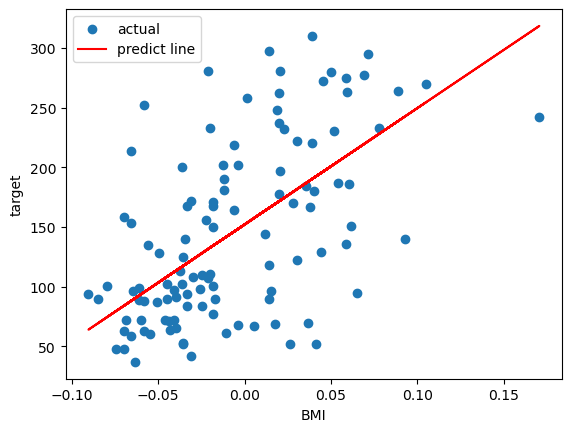

Coef: 975.2769831271274 Intercept: 152.07653296894014


In [9]:
# y값 예측해보기
# 실제 데이터와 예측선 시각화
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test)

plt.scatter(X_test, y_test, label='actual')
plt.plot(X_test, y_pred, color='red', label='predict line')
plt.xlabel('BMI')
plt.ylabel('target')
plt.legend()
plt.show()  

print('Coef:', lr.coef_[0], 'Intercept:', lr.intercept_)

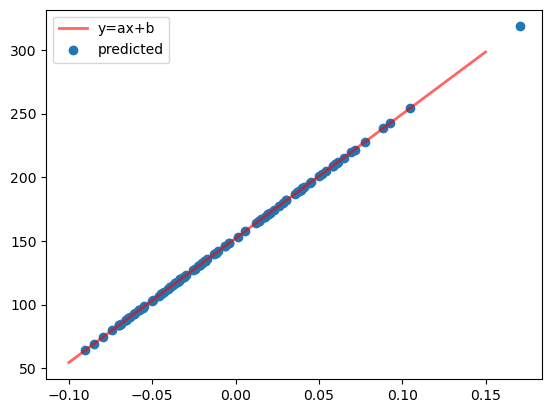

In [10]:
# 예측 데이터와 예측선 시각화
import numpy as np
a = lr.coef_[0]
b = lr.intercept_

x = np.linspace(-0.10,0.15)
y = a*x+b

plt.plot(x, y, color='red', linewidth=2, alpha=0.6, label='y=ax+b')
plt.scatter(X_test, y_pred, label='predicted')
plt.legend()
plt.show()

# 캐글 데이터

In [11]:
#라이브러리 호출
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

In [12]:
#데이터 불러오기
df = pd.read_csv('kaggle_data.csv')
df.head(5)

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [ ]:
#데이터 파악하기
def simple_summary(df):
    print("\n" + "="*50)
    print(f"       [ DATASET SUMMARY ]")
    print("="*50)
    print(f"▶ Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("-"*50)
    print(f"{'Column Name':<20} | {'Dtype':<10} | {'Nulls'}")
    print("-"*50)
    
    for col in df.columns:
        null_count = df[col].isnull().sum()
        dtype = str(df[col].dtype)
        # 결측치가 있으면 강조(★) 표시
        null_str = f"{null_count} (!!)" if null_count > 0 else f"{null_count}"
        print(f"{col[:20]:<20} | {dtype:<10} | {null_str}")
    
    print("="*50 + "\n")

# 수치형 결측치 중앙값으로 채우기
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# 범주형 결측치 최빈값으로 채우기
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
# 사용 예시
simple_summary(df)


       [ DATASET SUMMARY ]
▶ Shape: 230130 rows, 6 columns
--------------------------------------------------
Column Name          | Dtype      | Nulls
--------------------------------------------------
id                   | int64      | 0
date                 | object     | 0
country              | object     | 0
store                | object     | 0
product              | object     | 0
num_sold             | float64    | 8871 (!!)



In [14]:
categorical_cols = ['country', 'store', 'product','date']

# 2. LabelEncoder 적용
le = LabelEncoder()

for col in categorical_cols:
    # 각 컬럼별로 학습 및 변환
    df[col] = le.fit_transform(df[col])
    print(f"✅ {col:<10} 변환 완료")

print("\n" + "="*30)
print(df[categorical_cols].dtypes)

✅ country    변환 완료
✅ store      변환 완료
✅ product    변환 완료
✅ date       변환 완료

country    int64
store      int64
product    int64
date       int64
dtype: object


In [22]:
df = df.dropna(subset=['num_sold'])

X=df.drop(["num_sold"],axis=1)
y=df["num_sold"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=33)

In [18]:
rf = RandomForestRegressor(random_state=33, n_jobs=-1)

# 2. 하이퍼파라미터 그리드 (학습 속도를 위해 가볍게 설정)
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 15],
    'min_samples_split': [2, 4]
}

# 3. GridSearchCV 설정 (MAPE 기준)
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=3, 
    scoring='neg_mean_absolute_percentage_error', # MAPE 기준
    verbose=2
)

# 4. 학습 시작
print("🚀 MAPE 기준으로 GridSearchCV 최적화 시작...")
grid_search.fit(X_train, y_train)

# 5. 예측 및 최종 MAPE 계산
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 실제 MAPE (0.1이면 10% 오차를 의미)
final_mape = mean_absolute_percentage_error(y_test, y_pred)

print("\n" + "="*50)
print(f"✅ 최적 파라미터: {grid_search.best_params_}")
print(f"📊 최종 검증 MAPE: {final_mape:.4f} ({final_mape*100:.2f}%)")
print("="*50)

🚀 MAPE 기준으로 GridSearchCV 최적화 시작...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   3.7s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   3.7s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   3.6s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=   3.4s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=   3.3s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=   3.3s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   4.8s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   4.9s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=   4.7s
[CV] END max_depth=15, min_samples_split=4, n_estimators=100; total time=   4.7s
[CV] END max_depth=15, min_samples_split=4, n_estimators=100; total time=   4.7s
[CV] END max_d